# LSTM Referans Modeli — Test Sonuçları (Bölüm 3.5)

Bu notebook, Bölüm 3.5'te açıklanan tek yönlü LSTM referans modelinin  
deneysel sonuçlarını görselleştirir.

**Kaynak metrikler (rapor Bölüm 3.5):**  
- Doğruluk: %77.1  
- Kesinlik: %85.7  
- Duyarlılık: %78.8

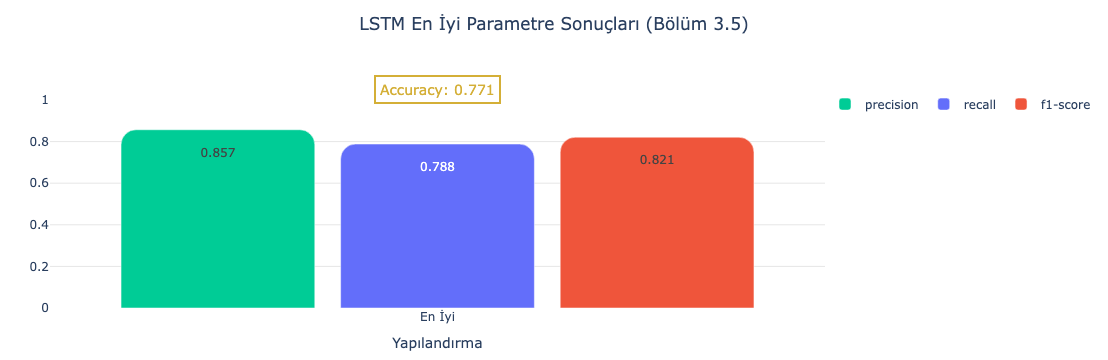

In [1]:
import pandas as pd
import plotly.graph_objects as go

# Bölüm 3.5 — LSTM referans model metrikleri
lstm_report = {
    "En İyi": {"precision": 0.857005, "recall": 0.788263, "f1-score": 0.821198},
    "accuracy": 0.770821,
}

def plot_lstm_report(title, report_dict):
    metrics_to_plot = ["precision", "recall", "f1-score"]
    df = (
        pd.DataFrame(report_dict).T.drop("accuracy").reset_index()
        .rename(columns={"index": "epoch"})
    )
    fig = go.Figure()
    colors = {"precision": "#00CC96", "recall": "#636EFA", "f1-score": "#EF553B"}

    for metric, color in colors.items():
        fig.add_trace(go.Bar(
            name=metric, x=df["epoch"], y=df[metric],
            text=df[metric].round(3), textposition="auto",
            marker_color=color, width=0.25,
            hovertemplate=f"<b>%{{x}}</b><br>{metric}: %{{y:.3f}}<extra></extra>",
        ))

    fig.add_annotation(
        x=0.5, y=1.12, xref="paper", yref="paper",
        text=f"Accuracy: {report_dict['accuracy']:.3f}",
        showarrow=False, font=dict(size=14, color="#d4af37"),
        bgcolor="rgba(255,255,255,0.9)", bordercolor="#d4af37",
        borderwidth=2, borderpad=4,
    )
    fig.update_layout(
        title=dict(text=title, y=0.95, x=0.5, xanchor="center"),
        barmode="group",
        yaxis=dict(range=[0, 1], gridcolor="rgba(0,0,0,0.1)", zeroline=False),
        xaxis=dict(title="Yapılandırma", type="category"),
        template="plotly_white",
        legend=dict(orientation="h", y=1.05, x=1, bgcolor="rgba(255,255,255,0.8)"),
        bargap=0.15, bargroupgap=0.1, barcornerradius=15,
        margin=dict(t=100, l=50, r=50, b=50),
    )
    fig.show()

plot_lstm_report("LSTM En İyi Parametre Sonuçları (Bölüm 3.5)", lstm_report)

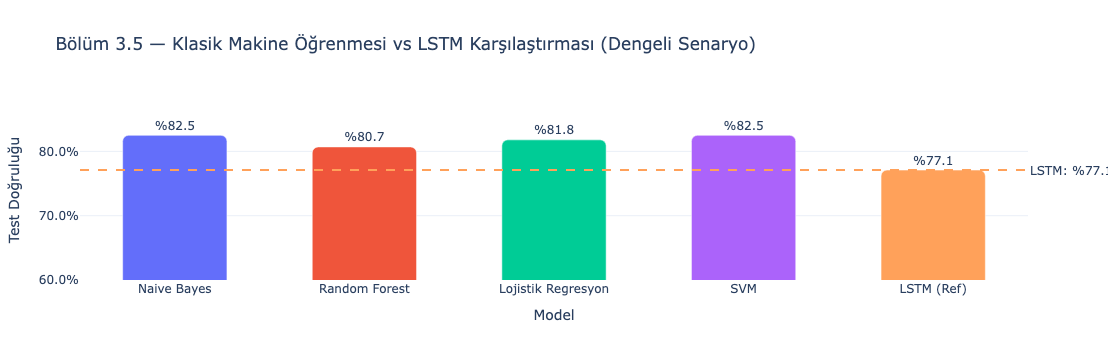

In [2]:
# Bölüm 3.5 — Klasik ML vs LSTM Karşılaştırmalı Grafik (güncel değerler)
models = ["Naive Bayes", "Random Forest", "Lojistik Regresyon", "SVM", "LSTM (Ref)"]
accuracies = [0.825, 0.807, 0.818, 0.825, 0.771]
colors_bar = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A"]

fig = go.Figure(go.Bar(
    x=models, y=accuracies,
    marker_color=colors_bar,
    text=[f"%{round(a*100,1)}" for a in accuracies],
    textposition="outside",
    width=0.55,
))
fig.update_layout(
    title="Bölüm 3.5 — Klasik Makine Öğrenmesi vs LSTM Karşılaştırması (Dengeli Senaryo)",
    xaxis_title="Model", yaxis_title="Test Doğruluğu",
    yaxis=dict(range=[0.6, 0.88], tickformat=".1%"),
    template="plotly_white",
    showlegend=False,
    barcornerradius=6,
)
# LSTM çizgisi
fig.add_hline(
    y=0.771, line_dash="dash", line_color="#FFA15A",
    annotation_text="LSTM: %77.1", annotation_position="right"
)
fig.show()

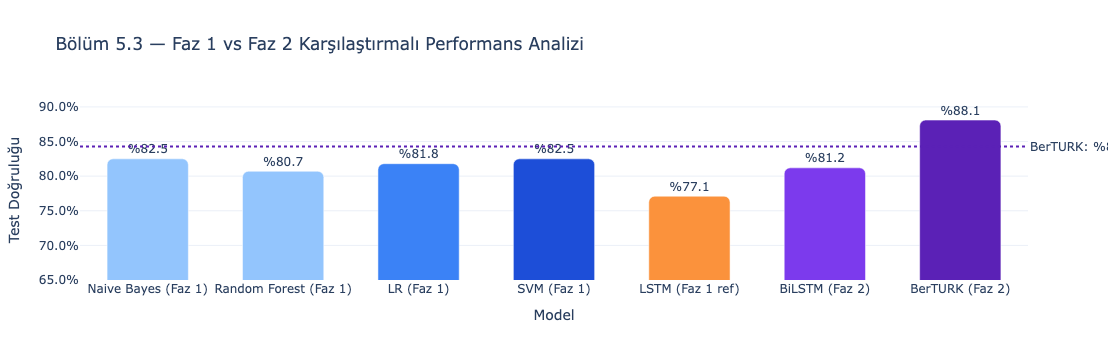

In [3]:
# Bölüm 5.3 — Faz 1 vs Faz 2 Karşılaştırmalı Grafik (güncel değerler)
all_models = [
    "Naive Bayes\n(Faz 1)", "Random Forest\n(Faz 1)",
    "LR\n(Faz 1)", "SVM\n(Faz 1)",
    "LSTM\n(Faz 1 ref)", "BiLSTM\n(Faz 2)", "BerTURK\n(Faz 2)"
]
all_accs = [0.825, 0.807, 0.818, 0.825, 0.771, 0.812, 0.881]
bar_colors = [
    "#93c5fd", "#93c5fd", "#3b82f6", "#1d4ed8",
    "#fb923c", "#7c3aed", "#5b21b6"
]

fig2 = go.Figure(go.Bar(
    x=all_models, y=all_accs,
    marker_color=bar_colors,
    text=[f"%{round(a*100,1)}" for a in all_accs],
    textposition="outside",
    width=0.6,
))
fig2.update_layout(
    title="Bölüm 5.3 — Faz 1 vs Faz 2 Karşılaştırmalı Performans Analizi",
    xaxis_title="Model", yaxis_title="Test Doğruluğu",
    yaxis=dict(range=[0.65, 0.91], tickformat=".1%"),
    template="plotly_white",
    showlegend=False,
    barcornerradius=6,
)
fig2.add_hline(
    y=0.843, line_dash="dot", line_color="#5b21b6",
    annotation_text="BerTURK: %84.3 (En Yüksek)", annotation_position="right"
)
fig2.show()

/var/folders/j6/s2n1klnn7r55n3lmgnx0pbyr0000gn/T/ipykernel_26183/445307002.py:65: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/j6/s2n1klnn7r55n3lmgnx0pbyr0000gn/T/ipykernel_26183/445307002.py:65: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/j6/s2n1klnn7r55n3lmgnx0pbyr0000gn/T/ipykernel_26183/445307002.py:65: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/j6/s2n1klnn7r55n3lmgnx0pbyr0000gn/T/ipykernel_26183/445307002.py:65: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/j6/s2n1klnn7r55n3lmgnx0pbyr0000gn/T/ipykernel_26183/445307002.py:65: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/j6/s2n1klnn7r55n3lmgnx0pbyr0000gn/T/ipykernel_26183/4453070

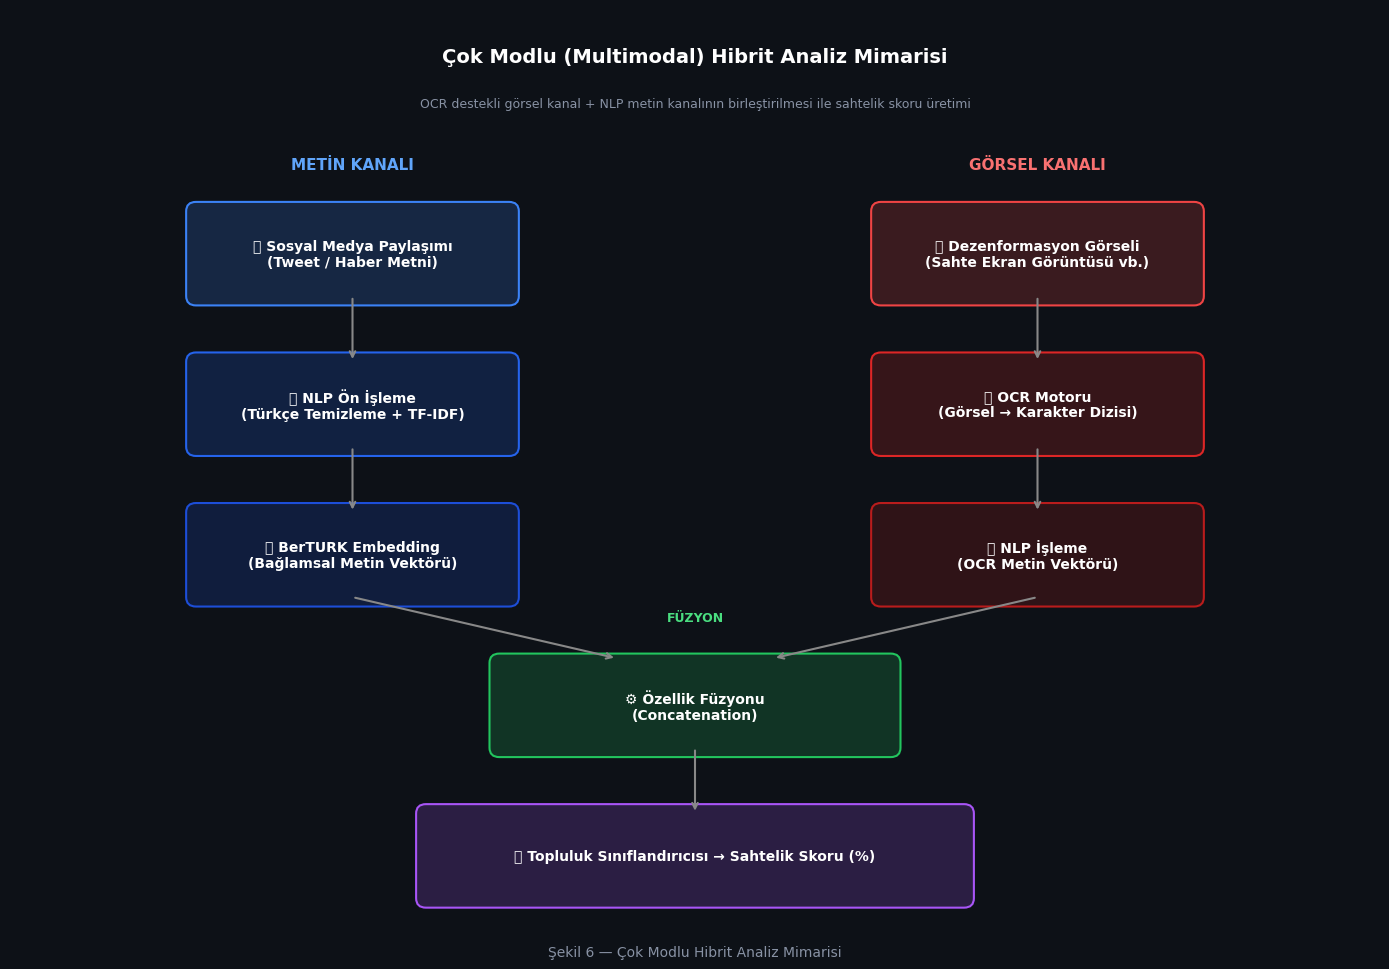

Şekil 6 kaydedildi: sekil6_multimodal.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

def draw_box(ax, x, y, w, h, label, color, text_color='white', fontsize=10):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.1", linewidth=1.5,
                          edgecolor=color, facecolor=color + '33')
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight='bold', wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, color='#888888'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Başlık
ax.text(7, 9.5, 'Çok Modlu (Multimodal) Hibrit Analiz Mimarisi',
        ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(7, 9.0, 'OCR destekli görsel kanal + NLP metin kanalının birleştirilmesi ile sahtelik skoru üretimi',
        ha='center', va='center', fontsize=9, color='#8892a4')

# Sütun başlıkları
ax.text(3.5, 8.3, 'METİN KANALI', ha='center', fontsize=11, color='#60a5fa', fontweight='bold')
ax.text(10.5, 8.3, 'GÖRSEL KANALI', ha='center', fontsize=11, color='#f87171', fontweight='bold')

# Sol kanal (Metin)
draw_box(ax, 3.5, 7.4, 3.2, 0.9, '📄 Sosyal Medya Paylaşımı\n(Tweet / Haber Metni)', '#3b82f6')
draw_arrow(ax, 3.5, 6.95, 3.5, 6.25)
draw_box(ax, 3.5, 5.8, 3.2, 0.9, '🔧 NLP Ön İşleme\n(Türkçe Temizleme + TF-IDF)', '#2563eb')
draw_arrow(ax, 3.5, 5.35, 3.5, 4.65)
draw_box(ax, 3.5, 4.2, 3.2, 0.9, '🤖 BerTURK Embedding\n(Bağlamsal Metin Vektörü)', '#1d4ed8')

# Sağ kanal (Görsel)
draw_box(ax, 10.5, 7.4, 3.2, 0.9, '🖼️ Dezenformasyon Görseli\n(Sahte Ekran Görüntüsü vb.)', '#ef4444')
draw_arrow(ax, 10.5, 6.95, 10.5, 6.25)
draw_box(ax, 10.5, 5.8, 3.2, 0.9, '🔍 OCR Motoru\n(Görsel → Karakter Dizisi)', '#dc2626')
draw_arrow(ax, 10.5, 5.35, 10.5, 4.65)
draw_box(ax, 10.5, 4.2, 3.2, 0.9, '📝 NLP İşleme\n(OCR Metin Vektörü)', '#b91c1c')

# Füzyon okları
draw_arrow(ax, 3.5, 3.75, 6.2, 3.1)
draw_arrow(ax, 10.5, 3.75, 7.8, 3.1)
ax.text(7, 3.5, 'FÜZYON', ha='center', fontsize=9, color='#4ade80', fontweight='bold')

# Füzyon kutusu
draw_box(ax, 7, 2.6, 4.0, 0.9, '⚙️ Özellik Füzyonu\n(Concatenation)', '#22c55e', text_color='white')

# Çıktı oku
draw_arrow(ax, 7, 2.15, 7, 1.45)

# Çıktı kutusu
draw_box(ax, 7, 1.0, 5.5, 0.9, '🎯 Topluluk Sınıflandırıcısı → Sahtelik Skoru (%)', '#a855f7')

plt.suptitle('Şekil 6 — Çok Modlu Hibrit Analiz Mimarisi', 
             y=0.02, fontsize=10, color='#8892a4')
plt.tight_layout()
plt.savefig('sekil6_multimodal.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Şekil 6 kaydedildi: sekil6_multimodal.png")